# From personnel links to municipal outcomes — entirely fictional

The wider research asks how administrative personnel persist or change through political transitions, and how that continuity relates to later economic outcomes. Validated person links can eventually support personnel aggregates and municipal outcome analysis. This notebook demonstrates that next step using a separate fictional population; it does not turn the two selected archival cases into a continuity estimate.

Six invented towns, 72 invented personnel records (12 per town) and 18 invented town-period observations show how linkage decisions enter an analysis table. **None of these values describes the archival source town or historical people in the main walkthrough.** All names, populations, periods, decisions and outcomes here are fictional and cannot be joined to those sources.

The outcome is newly completed dwellings per 1,000 residents, using each town-period's population as the denominator. It is a construction **flow**, not a housing stock. One of the 18 construction values is deliberately missing and stays missing. Accepted-link shares use the 12 earlier personnel per town as their denominator; review and not-observed cases remain explicit.

The final comparison holds the outcome fixed and changes one assumption: all pending reviews become accepted. That scenario is not a confidence interval, a bound on true continuity or a causal estimate. This is a workflow and visualisation demonstration, not a regression or historical finding.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ocr import ROOT
from visualise import export
from outcome_visualise import decision_shares, housing_panels, linkage_scenario
%matplotlib inline
staff = pd.read_csv(ROOT/'data/fictional_staff.csv')
housing = pd.read_csv(ROOT/'data/fictional_housing.csv')
assert not staff['person_id'].duplicated().any()
assert not housing.duplicated(['town', 'period']).any()
assert housing['population'].gt(0).all()
assert housing['completed_dwellings'].dropna().ge(0).all()
display(staff.head())
display(housing.head())

,town,person_id,decision
0,Fictional 01,F01-01,accepted
1,Fictional 01,F01-02,accepted
2,Fictional 01,F01-03,accepted
3,Fictional 01,F01-04,review
4,Fictional 01,F01-05,review


,town,period,population,completed_dwellings
0,Fictional 01,Year 1,15600,85.0
1,Fictional 01,Year 2,15858,148.0
2,Fictional 01,Year 3,15773,164.0
3,Fictional 02,Year 1,19081,193.0
4,Fictional 02,Year 2,19160,174.0


## 1. Aggregate decisions without treating uncertainty as zero continuity

Count distinct earlier personnel. Divide accepted links by that baseline for the **accepted-link share**; report review and not-observed shares separately. These are decision summaries, not true continuity estimates. A failed link need not mean the person left.

The bars use a common 0–100% scale and are sorted by accepted share. Segment labels report people, while the right-hand column shows the accepted fraction with its denominator. Hatching distinguishes review items without depending on colour.

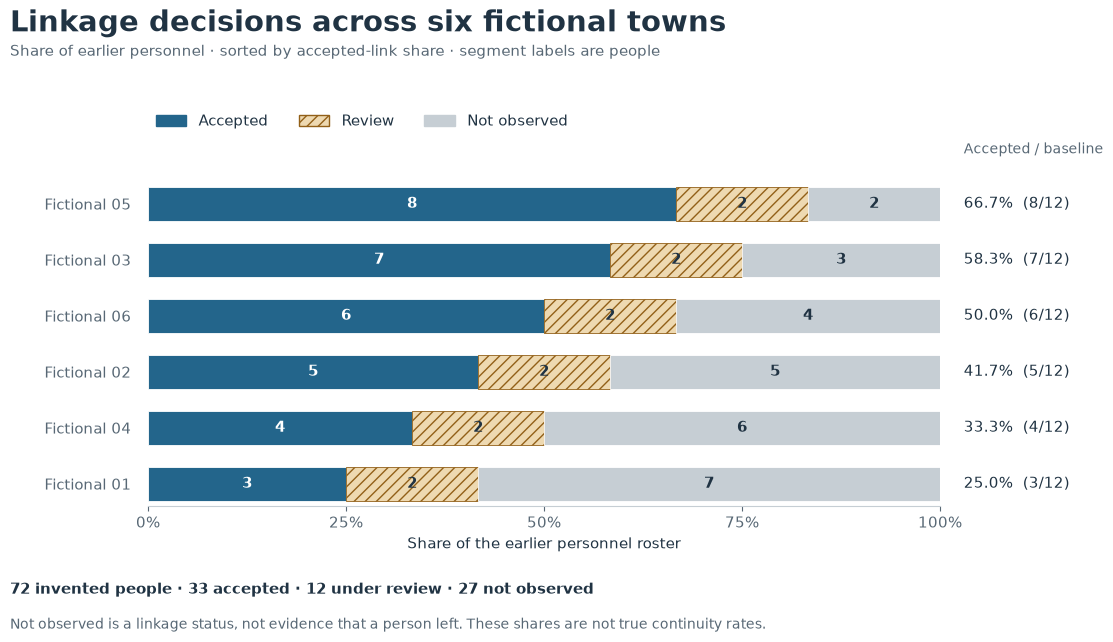

In [2]:
summary = pd.crosstab(staff['town'], staff['decision']).reindex(
    columns=['accepted', 'review', 'not_observed'], fill_value=0)
summary['baseline_people'] = summary.sum(axis=1)
for decision in ['accepted', 'review', 'not_observed']:
    summary[decision+'_share'] = summary[decision]/summary['baseline_people']
assert summary['baseline_people'].eq(12).all()
assert (summary[['accepted_share', 'review_share', 'not_observed_share']].sum(axis=1)-1).abs().lt(1e-12).all()
fig = decision_shares(summary)
export(fig, 'fictional_decisions')
display(fig)
plt.close(fig)

## 2. Join outcomes and check denominators

Use a many-to-one join from town-period rows to one staff summary per town. Require every town to match. Compute the housing rate using the population observed for that same invented period. Missing construction remains missing, not zero; no annual stock is reconstructed from flows.

In [3]:
panel = housing.merge(summary.reset_index(), on='town', how='left',
                      validate='many_to_one', indicator=True)
assert panel['_merge'].eq('both').all()
panel = panel.drop(columns='_merge')
panel['dwellings_per_1000'] = 1000*panel['completed_dwellings']/panel['population']
assert panel['dwellings_per_1000'].isna().sum() == 1
panel.to_csv(ROOT/'outputs/fictional_panel.csv', index=False, lineterminator='\n')
display(panel[['town', 'period', 'population', 'completed_dwellings', 'dwellings_per_1000']].round(3))

,town,period,population,completed_dwellings,dwellings_per_1000
0,Fictional 01,Year 1,15600,85.0,5.449
1,Fictional 01,Year 2,15858,148.0,9.333
2,Fictional 01,Year 3,15773,164.0,10.398
3,Fictional 02,Year 1,19081,193.0,10.115
4,Fictional 02,Year 2,19160,174.0,9.081
5,Fictional 02,Year 3,19300,82.0,4.249
6,Fictional 03,Year 1,22661,173.0,7.634
7,Fictional 03,Year 2,22662,142.0,6.266
8,Fictional 03,Year 3,22800,165.0,7.237
9,Fictional 04,Year 1,26145,77.0,2.945


## 3. Compare outcomes on common scales

Each small multiple shows one town and the same three discrete periods, using the same y-axis and units. Stems begin at zero; direct labels give the rates. This separates town comparisons from colour lookups and avoids a six-line overlay. Year 3 is filled, so the latest period remains identifiable in grayscale.

Fictional 04 has no observed construction value in Year 2. Its panel leaves the mark absent and explicitly labels it missing. No interpolation or zero imputation is used. Rates use each period's population, rather than averaging raw counts across different town sizes.

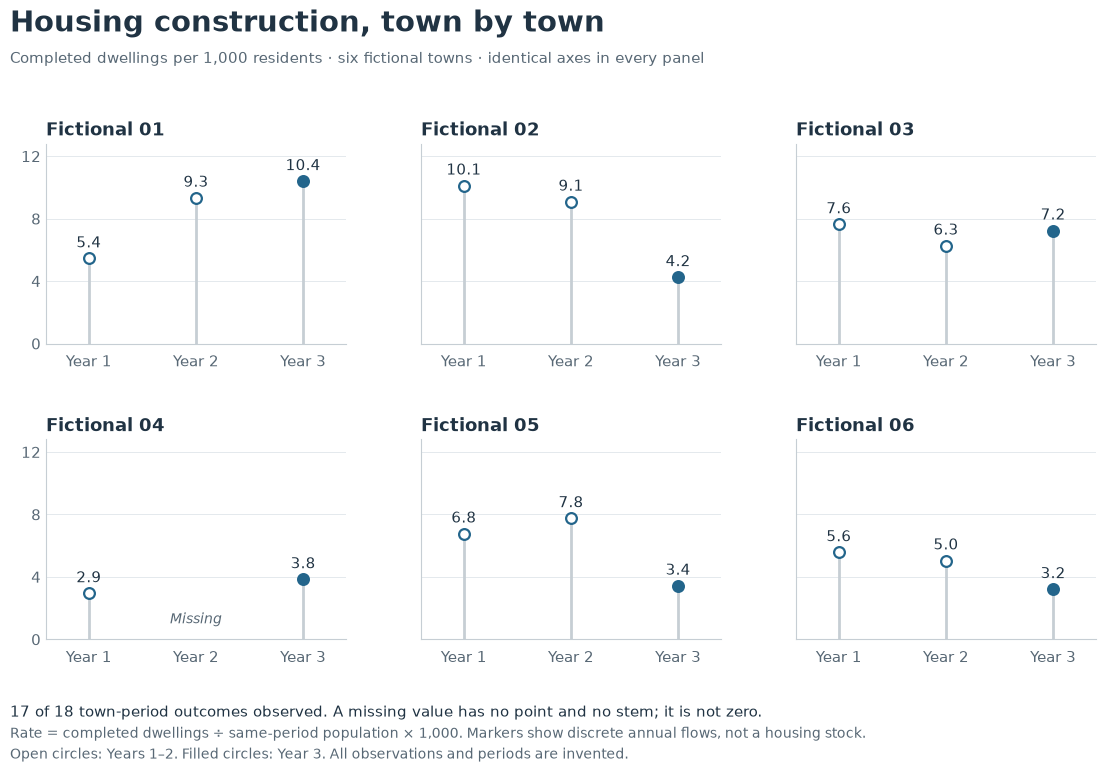

In [4]:
fig = housing_panels(panel)
export(fig, 'fictional_outcomes')
display(fig)
plt.close(fig)

## 4. Make a linkage assumption visible

Compare the accepted-link share with a scenario in which **all review items become accepted**. A connector joins the two positions for the same town while its housing outcome stays fixed. These are alternative assumptions, not confidence intervals or bounds on true continuity; extraction and candidate generation may miss additional people.

The plot uses only Year 3, with one observation per town. The fixed staff share is not an annual staffing measure. No regression or effect estimate is fitted to these six invented towns.

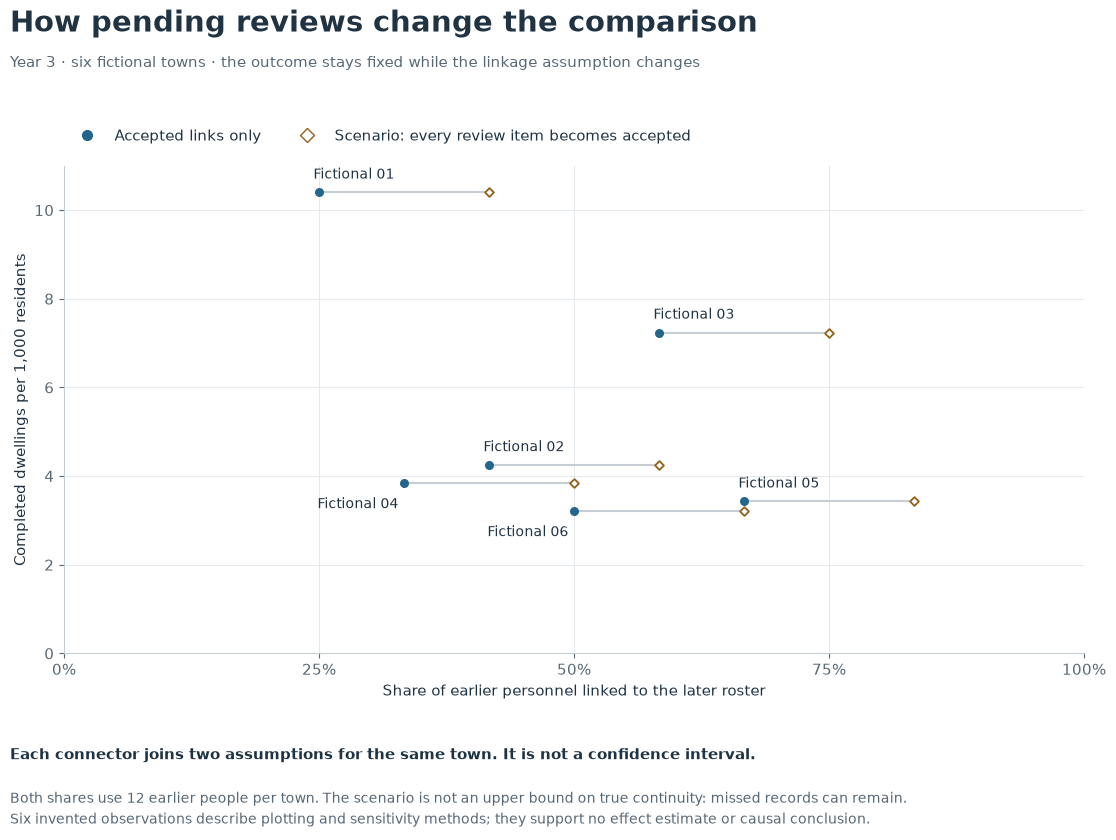

,town,accepted,review,baseline_people,accepted_share,review_accepted_share,completed_dwellings,population,dwellings_per_1000
2,Fictional 01,3,2,12,0.250,0.417,164.0,15773,10.398
5,Fictional 02,5,2,12,0.417,0.583,82.0,19300,4.249
8,Fictional 03,7,2,12,0.583,0.750,165.0,22800,7.237
11,Fictional 04,4,2,12,0.333,0.500,102.0,26561,3.840
14,Fictional 05,8,2,12,0.667,0.833,103.0,30052,3.427
17,Fictional 06,6,2,12,0.500,0.667,107.0,33351,3.208


In [5]:
fig, cross = linkage_scenario(panel)
export(fig, 'fictional_sensitivity')
display(fig)
plt.close(fig)
display(cross[['town', 'accepted', 'review', 'baseline_people', 'accepted_share',
               'review_accepted_share', 'completed_dwellings', 'population', 'dwellings_per_1000']].round(3))

## Visualisation exercises

1. Change the outcome from dwellings per 1,000 residents to raw dwellings. Explain which comparison changes when town size is no longer accounted for.
2. Reproduce the sensitivity plot for Year 2. Explicitly report the missing town instead of treating its outcome as zero.
3. Check the figures in grayscale: direct labels, hatching and open/filled markers should preserve the intended distinctions.

`outcome_visualise.py` contains the plotting code. All three figures export to PNG and SVG in `outputs/`; their data come only from the two fictional input CSVs. The exact denominators and rates remain available in `fictional_panel.csv` and the table above.

A research analysis additionally needs validated linkage, consistent outcome definitions and dates, representative coverage and a defensible identification strategy.